# KNN 与 Neural Network (MLP) 对比实验

这个 notebook 直接读取已经处理好的训练数据，分别训练 KNN 和 Neural Network（MLP）两个模型。

实验要求：
- 每个模型单独成块执行
- 使用 SMOTE 处理类别不平衡
- 使用交叉验证做超参数调优
- 评价两个维度：Accuracy 和 Interpretation
- 过程中的说明和注释全部用中文

In [ ]:
# 导入需要的库
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from IPython.display import display

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, average_precision_score, roc_curve, auc,
                             precision_recall_curve, confusion_matrix, classification_report,
                             roc_auc_score)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.unicode_minus'] = False

SEED = 42
np.random.seed(SEED)

print('Libraries loaded.')

In [2]:
# 读取训练数据
def load_processed_data():
    candidate_dirs = [
        os.path.abspath(os.path.join(os.getcwd(), '..', 'data')),
        os.path.abspath(os.path.join(os.getcwd(), 'data')),
        'data'
    ]
    for data_dir in candidate_dirs:
        x_path = os.path.join(data_dir, 'X_train_processed.csv')
        y_path = os.path.join(data_dir, 'y_train_processed.csv')
        if os.path.exists(x_path) and os.path.exists(y_path):
            X = pd.read_csv(x_path)
            y = pd.read_csv(y_path).iloc[:, 0]
            print(f'成功读取数据：{os.path.abspath(data_dir)}')
            return X, y
    raise FileNotFoundError('没有找到 processed 训练数据，请确认 data 目录中存在 X_train_processed.csv 和 y_train_processed.csv。')

X, y = load_processed_data()

print('X 的形状：', X.shape)
print('y 的形状：', y.shape)
print('特征列：', list(X.columns))
print('标签分布：')
display(y.value_counts().rename('count').to_frame())
print('标签比例：')
display((y.value_counts(normalize=True).rename('ratio') * 100).round(2).to_frame())

成功读取数据：c:\Users\Lenovo\Desktop\6122-group-project\data
X 的形状： (120000, 10)
y 的形状： (120000,)
特征列： ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
标签分布：


,count
SeriousDlqin2yrs,
0,111979
1,8021


标签比例：


,ratio
SeriousDlqin2yrs,
0,93.32
1,6.68


In [ ]:
def train_with_cv(name, estimator, param_grid, X, y, random_state=42, cv_splits=5):
    print(f'\n========== Training: {name} ==========')

    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=random_state)),
        ('clf', estimator)
    ])

    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    scoring = {'accuracy': 'accuracy', 'roc_auc': 'roc_auc', 'average_precision': 'average_precision'}

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        refit='roc_auc',
        cv=cv,
        return_train_score=True,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X, y)
    best_model = search.best_estimator_

    try:
        probas_cv = cross_val_predict(best_model, X, y, cv=cv, method='predict_proba', n_jobs=-1)
        y_scores = probas_cv[:, 1]
        fpr, tpr, _ = roc_curve(y, y_scores)
        roc_auc_cv = auc(fpr, tpr)
        precision, recall, _ = precision_recall_curve(y, y_scores)
        pr_auc_cv = average_precision_score(y, y_scores)

        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc_cv:.4f})', color='#457b9d')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} - ROC Curve')
        plt.legend(loc='lower right')

        plt.subplot(1, 2, 2)
        plt.plot(recall, precision, label=f'PR (AP = {pr_auc_cv:.4f})', color='#e76f51')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'{name} - Precision-Recall Curve')
        plt.legend(loc='lower left')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('Failed to plot ROC/PR curves:', e)
        y_scores = None
        roc_auc_cv = np.nan
        pr_auc_cv = np.nan

    y_pred = best_model.predict(X)
    train_acc = accuracy_score(y, y_pred)
    try:
        y_proba_full = best_model.predict_proba(X)[:, 1]
        train_ap = average_precision_score(y, y_proba_full)
    except Exception:
        y_proba_full = None
        train_ap = np.nan

    best_idx = search.best_index_
    mean_roc = search.cv_results_.get('mean_test_roc_auc', [np.nan])[best_idx]
    mean_acc = search.cv_results_.get('mean_test_accuracy', [np.nan])[best_idx]
    mean_ap = search.cv_results_.get('mean_test_average_precision', [np.nan])[best_idx]

    print('Best params:', search.best_params_)
    print(f'CV (mean) ROC_AUC: {mean_roc:.4f} | CV Accuracy: {mean_acc:.4f} | CV AP: {mean_ap:.4f}')
    print(f'Train Accuracy: {train_acc:.4f} | Train AP: {train_ap:.4f}')

    result = {
        'model': name,
        'best_params': search.best_params_,
        'cv_roc_auc': mean_roc,
        'cv_accuracy': mean_acc,
        'cv_average_precision': mean_ap,
        'train_accuracy': train_acc,
        'train_average_precision': train_ap,
        'cv_roc_auc_curve': (fpr, tpr) if y_scores is not None else None,
        'cv_pr_curve': (precision, recall) if y_scores is not None else None,
        'best_estimator': best_model
    }

    print(f'========== {name} training complete ==========')
    return result

## 模型一：KNN（K-Nearest Neighbors）

KNN 是基于距离的非参数分类器。通过 GridSearchCV 调整 K 值、权重方式和距离度量。

解释性方面：
1. KNN 没有显式的模型参数（系数），它的预测依赖于测试样本的局部邻域。
2. 可以通过分析最优 K 值和距离度量来理解模型行为。
3. 由于数据量较大，GridSearchCV 使用 3 折交叉验证以控制运行时间。


========== 开始训练：KNN ==========
Fitting 3 folds for each of 16 candidates, totalling 48 fits


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_38972\2664143387.py:53: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_38972\2664143387.py:53: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


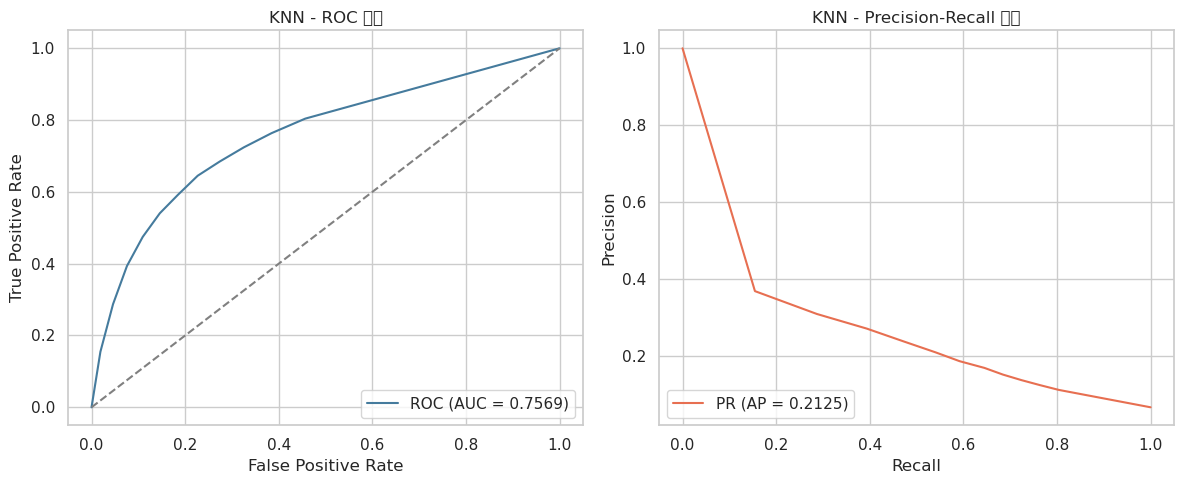

最优超参数： {'clf__metric': 'manhattan', 'clf__n_neighbors': 11, 'clf__weights': 'uniform'}
交叉验证 (mean) ROC_AUC：0.7570 | CV Accuracy：0.8004 | CV AP：0.2126
训练集 Accuracy：0.8481 | 训练集 AP：0.7375
========== KNN 训练完成 ==========


In [4]:
# KNN
knn = KNeighborsClassifier()
knn_grid = {
    'clf__n_neighbors': [3, 5, 7, 11],
    'clf__weights': ['uniform', 'distance'],
    'clf__metric': ['euclidean', 'manhattan']
}

knn_result = train_with_cv('KNN', knn, knn_grid, X, y, cv_splits=3)

## 模型二：Neural Network（MLP Classifier）

MLP 是多层前馈神经网络。通过 GridSearchCV 调整隐藏层结构和正则化参数。

解释性方面：
1. MLP 是黑箱模型，没有直接可解释的系数。
2. 可以通过比较不同结构的性能差异来理解网络复杂度与泛化能力的关系。
3. 使用 early_stopping 防止过拟合，adaptive 学习率自动调整步长。


========== 开始训练：Neural Network (MLP) ==========
Fitting 3 folds for each of 6 candidates, totalling 18 fits


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_38972\2664143387.py:53: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_38972\2664143387.py:53: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


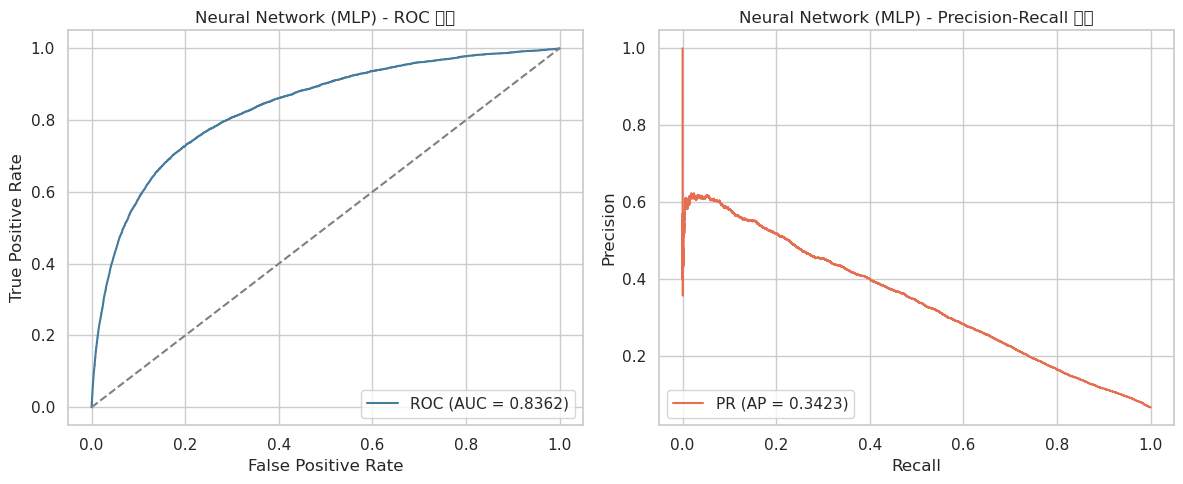

最优超参数： {'clf__activation': 'relu', 'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (100,), 'clf__learning_rate': 'adaptive', 'clf__max_iter': 200}
交叉验证 (mean) ROC_AUC：0.8360 | CV Accuracy：0.8029 | CV AP：0.3430
训练集 Accuracy：0.7892 | 训练集 AP：0.3765
========== Neural Network (MLP) 训练完成 ==========


In [5]:
# Neural Network (MLP)
mlp = MLPClassifier(random_state=SEED, early_stopping=True)
mlp_grid = {
    'clf__hidden_layer_sizes': [(64, 32), (128, 64), (100,)],
    'clf__activation': ['relu'],
    'clf__alpha': [0.001, 0.01],
    'clf__learning_rate': ['adaptive'],
    'clf__max_iter': [200]
}

mlp_result = train_with_cv('Neural Network (MLP)', mlp, mlp_grid, X, y, cv_splits=3)

## 结果对比与分析

这一部分对比 KNN 和 MLP 的交叉验证性能。

KNN 和 MLP 都属于非线性模型：
- KNN 靠局部相似性做预测，适合数据分布不规则的场景。
- MLP 能学到更复杂的非线性决策边界，但需要更多计算资源且不易解释。

In [ ]:
comparison = pd.DataFrame([
    {
        'Model': knn_result['model'],
        'CV ROC_AUC': knn_result.get('cv_roc_auc', np.nan),
        'CV AP': knn_result.get('cv_average_precision', np.nan),
        'CV Accuracy': knn_result.get('cv_accuracy', np.nan),
        'Train Accuracy': knn_result.get('train_accuracy', np.nan),
        'Train AP': knn_result.get('train_average_precision', np.nan),
    },
    {
        'Model': mlp_result['model'],
        'CV ROC_AUC': mlp_result.get('cv_roc_auc', np.nan),
        'CV AP': mlp_result.get('cv_average_precision', np.nan),
        'CV Accuracy': mlp_result.get('cv_accuracy', np.nan),
        'Train Accuracy': mlp_result.get('train_accuracy', np.nan),
        'Train AP': mlp_result.get('train_average_precision', np.nan),
    }
])

display(comparison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=comparison, x='Model', y='CV ROC_AUC', ax=axes[0], palette=['#457b9d', '#e76f51'])
axes[0].set_title('Cross-Validation ROC AUC Comparison')
axes[0].set_ylim(0, 1)

sns.barplot(data=comparison, x='Model', y='CV AP', ax=axes[1], palette=['#457b9d', '#e76f51'])
axes[1].set_title('Cross-Validation PR-AUC (Average Precision) Comparison')
axes[1].set_ylim(0, 1)

for ax in axes:
    ax.set_xlabel('Model')
plt.tight_layout()
plt.show()

In [ ]:
def load_test_data():
    candidate_dirs = [
        os.path.abspath(os.path.join(os.getcwd(), '..', 'data')),
        os.path.abspath(os.path.join(os.getcwd(), 'data')),
        'data'
    ]
    for data_dir in candidate_dirs:
        x_path = os.path.join(data_dir, 'X_test_processed.csv')
        y_path = os.path.join(data_dir, 'y_test_processed.csv')
        if os.path.exists(x_path) and os.path.exists(y_path):
            X_t = pd.read_csv(x_path)
            y_t = pd.read_csv(y_path).iloc[:, 0]
            print(f'Test data loaded: {os.path.abspath(data_dir)}')
            return X_t, y_t
    raise FileNotFoundError('Test data not found.')

X_test, y_test = load_test_data()
print('X_test shape:', X_test.shape)
print('y_test distribution:')
display(y_test.value_counts().rename('count').to_frame())

def eval_on_test(result, X_t, y_t):
    name = result['model']
    best = result['best_estimator']
    print(f"\n--- Evaluating on test set: {name} ---")
    y_pred = best.predict(X_t)
    try:
        y_proba = best.predict_proba(X_t)[:, 1]
    except Exception:
        y_proba = None

    acc = accuracy_score(y_t, y_pred)
    print(f'Accuracy: {acc:.4f}')
    if y_proba is not None:
        roc_auc = roc_auc_score(y_t, y_proba)
        ap = average_precision_score(y_t, y_proba)
        print(f'ROC AUC: {roc_auc:.4f} | PR-AUC (AP): {ap:.4f}')

        fpr, tpr, _ = roc_curve(y_t, y_proba)
        precision, recall, _ = precision_recall_curve(y_t, y_proba)
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.4f})', color='#457b9d')
        plt.plot([0, 1], [0, 1], '--', color='gray')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} - Test ROC Curve')
        plt.legend(loc='lower right')

        plt.subplot(1, 2, 2)
        plt.plot(recall, precision, label=f'PR (AP={ap:.4f})', color='#e76f51')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'{name} - Test Precision-Recall Curve')
        plt.legend(loc='lower left')
        plt.tight_layout()
        plt.show()
    else:
        print('Model does not support predict_proba.')

    cm = confusion_matrix(y_t, y_pred)
    print('Confusion Matrix:\n', cm)
    print('Classification Report:')
    print(classification_report(y_t, y_pred, digits=4))

    return {
        'test_accuracy': acc,
        'test_roc_auc': roc_auc if (y_proba is not None) else np.nan,
        'test_ap': ap if (y_proba is not None) else np.nan,
    }

knn_test_metrics = eval_on_test(knn_result, X_test, y_test)
mlp_test_metrics = eval_on_test(mlp_result, X_test, y_test)

print('\nSummary (Test Set):')
display(pd.DataFrame([
    {'Model': knn_result['model'], 'Test ROC_AUC': knn_test_metrics['test_roc_auc'], 'Test AP': knn_test_metrics['test_ap'], 'Test Accuracy': knn_test_metrics['test_accuracy']},
    {'Model': mlp_result['model'], 'Test ROC_AUC': mlp_test_metrics['test_roc_auc'], 'Test AP': mlp_test_metrics['test_ap'], 'Test Accuracy': mlp_test_metrics['test_accuracy']}
]).round(4))